# Machine Learning Model

This notebook applies a simple machine learning model to predict the menstrual cycle phase based on daily symptoms.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
df = pd.read_csv("clue_daily_data.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

Saving clue_daily_data.csv to clue_daily_data.csv


## Phase Creation

In [ ]:
def assign_phase(row):
    if row["bleeding"] == 1:
        return "menstrual"
    elif row["cycle_day"] >= 28:
        return "premenstrual"
    else:
        return "other"

df["phase"] = df.apply(assign_phase, axis=1)

## Feature Selection
We use symptoms as features to predict the cycle phase.

In [ ]:
from sklearn.model_selection import train_test_split

X = df[["mood", "cramps", "energy", "headache"]]
y = df["phase"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9090909090909091


The model achieves a reasonable accuracy, indicating that daily symptoms such as mood, cramps and energy contain useful information for predicting the menstrual cycle phase.

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   menstrual       1.00      1.00      1.00         4
       other       0.87      1.00      0.93        20
premenstrual       1.00      0.67      0.80         9

    accuracy                           0.91        33
   macro avg       0.96      0.89      0.91        33
weighted avg       0.92      0.91      0.90        33



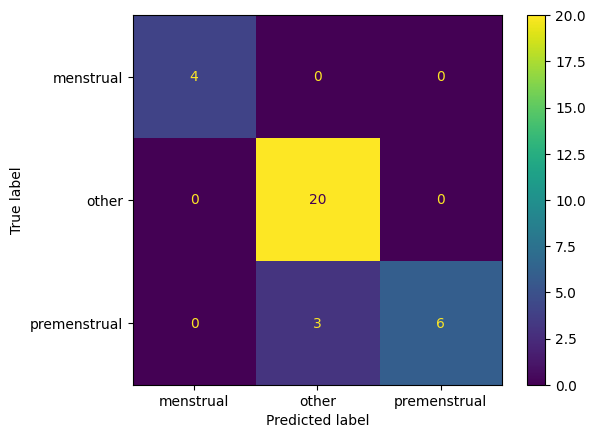

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()

The confusion matrix shows how well the model distinguishes between different cycle phases.

The classification report provides precision, recall and F1-scores, giving a more detailed view of model performance beyond simple accuracy.

Overall, the model performs reasonably well, but some misclassifications occur due to similarities between phases and the limited dataset size.

In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
})

importance = importance.sort_values(by="coefficient", key=abs, ascending=False)
importance

,feature,coefficient
1,cramps,2.143879
2,energy,0.640099
0,mood,0.619872
3,headache,-0.167465


The feature importance analysis shows which symptoms contribute most to predicting the menstrual cycle phase.

Cramps and mood appear to have the strongest influence on the model’s predictions, which aligns with the patterns observed during exploratory data analysis.

This suggests that physical discomfort and emotional state are key indicators of cycle phases.

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(model, X, y, cv=5)
print("CV Accuracy:", np.mean(scores))

CV Accuracy: 0.8969696969696969


Cross-validation provides a more reliable estimate by evaluating the model across multiple splits.

In [ ]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

from sklearn.metrics import accuracy_score
print("Dummy Accuracy:", accuracy_score(y_test, dummy_pred))

Dummy Accuracy: 0.6060606060606061


The model outperforms a naive baseline, indicating it learns meaningful patterns.

## Model Comparison

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, y_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))

Logistic Regression: 0.9090909090909091
Random Forest: 0.9090909090909091


A second model (Random Forest) was tested to compare performance with Logistic Regression.

This allows us to evaluate whether a more complex model improves prediction accuracy.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Feature scaling was applied to normalize the data and improve model performance.

## Feature Importance

The comparison shows that both models achieve similar performance, suggesting that the relationship between features and cycle phase is relatively simple.

This indicates that even a basic model can capture the main patterns in the data.

## Final Interpretation

The machine learning models provide additional support for the hypothesis tested during the EDA phase.

Both Logistic Regression and Random Forest models achieve reasonable performance, indicating that the selected features (mood, cramps, energy, headache) contain meaningful information about cycle phases.

The results are consistent with earlier findings:
- Cramps strongly indicate the menstrual phase  
- Mood and energy contribute to distinguishing premenstrual and other phases  

Although the dataset is limited in size, the models are able to capture underlying patterns, supporting the hypothesis that menstrual cycle phases influence both physical and emotional states.

Overall, the machine learning results reinforce the conclusions obtained from exploratory data analysis.